# All merged

# with tiles and masks

In [ ]:
base_path = "/home/student/sky-scan/data"


from PIL import Image
import os

def get_all_char_before_dot(s):
    dot_index = s.find('.')
    if dot_index > 0:
        return s[:dot_index]
    else:
        return None  # Return None if there's no character before the dot

def generate_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image
    image = Image.open(image_path)
    image_width, image_height = image.size

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to the bounding box to create the tile
            tile = image.crop(bbox)

            # Save the tile to the output folder
            image_file_name=os.path.basename(image_path)
            image_idx = get_all_char_before_dot(image_file_name)
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png") #image_id_x_y.png

    print(f"✅ Tiles from {image_file_name} are generated successfully.")

def generate_binary_tiles(image_path, tile_width, tile_height, step, output_folder):
    # Open the image in grayscale mode (black & white)
    image = Image.open(image_path).convert("L")  # "L" mode ensures grayscale (0-255)
    image_width, image_height = image.size

    # Generate tiles
    for x in range(0, image_width - tile_width + 1, step):
        for y in range(0, image_height - tile_height + 1, step):
            # Define the bounding box for the current tile
            left = x
            upper = y
            right = left + tile_width
            lower = upper + tile_height
            bbox = (left, upper, right, lower)

            # Crop the image to create the tile
            tile = image.crop(bbox)

            # Convert to binary (0 or 255) to ensure black and white format
            tile = tile.point(lambda p: 255 if p > 127 else 0, mode="1")  # Thresholding

            # Save the tile to the output folder
            image_file_name = os.path.basename(image_path)
            image_idx = image_file_name.split('.')[0]  # Get filename without extension
            tile.save(f"{output_folder}/{image_idx}_{x}_{y}.png", format="PNG")  # Save as binary PNG

    print(f"✅ Binary tiles from {image_file_name} are generated successfully.")

# Generate tiles for original images
os.makedirs(f'{base_path}/patch', exist_ok=True)

for i in range(1,13): #12 images
    generate_tiles(f'{base_path}/Tiles/{i}.jpg', 256, 256, 128, f'{base_path}/patch')

print("Original images are generated successfully.")

# Generate tiles for binary mask images
os.makedirs(f'{base_path}/patch-binary', exist_ok=True)

for i in range(1,13): #12 images
    generate_binary_tiles(f'{base_path}/mask/{i}.png', 256, 256, 128, f'{base_path}/patch-binary')

print("Binary mask images are generated successfully.")


In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!python --version

In [7]:
# !pip install numpy matplotlib opencv-python pillow torch torchvision
!pip install tqdm

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
base_path = "/home/student/sky-scan/data"

# -----------------
# Check if CUDA is Available
# -----------------

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"✅ Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected, running on CPU.")

# -----------------
# Define Dataset Paths
# -----------------
image_dir = f"{base_path}/patch"  # Folder with image tiles
mask_dir = f"{base_path}/patch-binary"  # Folder with corresponding mask tiles



# -----------------
# Function to Load Dataset
# -----------------
from tqdm import tqdm  # Import tqdm
import warnings
# Suppress all warnings
warnings.simplefilter('ignore', Image.DecompressionBombWarning)
# warnings.filterwarnings("ignore",message="libpng warning: iCCP: known incorrect sRGB profile")

def load_tiled_data(image_dir, mask_dir, image_size=(256, 256)):
    image_files = os.listdir(image_dir)
    num_images = len(image_files)

    # Preallocate memory for images and masks
    images = np.zeros((num_images, image_size[0], image_size[1], 3), dtype=np.float32)  # (num_images, height, width, channels)
    masks = np.zeros((num_images, image_size[0], image_size[1], 1), dtype=np.uint8)  # (num_images, height, width, channels)

    # Use tqdm to create a progress bar for the loop
    for idx, image_file in enumerate(tqdm(image_files, desc="Loading images", unit="image")):
        img_path = os.path.join(image_dir, image_file)
        mask_path = os.path.join(mask_dir, image_file)  # Mask should have the same filename

        if not os.path.exists(mask_path):
            continue  # Skip if corresponding mask is missing

        # Load and preprocess image
        image = Image.open(img_path).convert("RGB")  # Open image using PIL
        image = np.array(image) / 255.0 # Normalize

        # Load and preprocess mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, image_size)
        mask = (mask > 127).astype(np.uint8)  # Convert to binary
        mask = np.expand_dims(mask, axis=-1)  # Add channel dimension

        # Store the image and mask in the preallocated arrays
        images[idx] = image
        masks[idx] = mask

    return images, masks


# Load dataset
X, Y = load_tiled_data(image_dir, mask_dir)
print(f"✅ Loaded {len(X)} images and {len(Y)} masks.")

✅ Running on GPU: Tesla V100-PCIE-16GB


Loading images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16200/16200 [01:45<00:00, 153.04image/s]

✅ Loaded 16200 images and 16200 masks.


# traning model with IOU score

In [1]:
import pickle
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Directory to save checkpoints
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Define Pix2Pix Generator in PyTorch
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.down1 = self.conv_block(3, 64)
        self.down2 = self.conv_block(64, 128)
        self.down3 = self.conv_block(128, 256)
        self.up1 = self.deconv_block(256, 128)
        self.up2 = self.deconv_block(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)
        self.sigmoid = nn.Sigmoid()

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def deconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return self.sigmoid(x)

# Initialize the generator and move it to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)

# Define Pix2Pix Discriminator in PyTorch
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=1)
        )

    def forward(self, x):
        return self.model(x)

discriminator = Discriminator().to(device)

# Define Loss & Optimizers
loss_fn = nn.BCEWithLogitsLoss()
generator_optimizer = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

def calculate_iou(pred_mask, true_mask):
    pred_mask = pred_mask > 0.5
    true_mask = true_mask > 0.5
    intersection = (pred_mask & true_mask).sum().item()
    union = (pred_mask | true_mask).sum().item()
    iou = intersection / union if union > 0 else 1.0
    return iou

def train_step(input_image, target):
    input_image = torch.tensor(input_image).to(device).permute(0, 3, 1, 2)
    target = torch.tensor(target).to(device).permute(0, 3, 1, 2)
    gen_output = generator(input_image)
    disc_real_output = discriminator(torch.cat((input_image, target), dim=1))
    disc_generated_output = discriminator(torch.cat((input_image, gen_output), dim=1))
    gen_loss = loss_fn(disc_generated_output, torch.ones_like(disc_generated_output)) + torch.mean(torch.abs(target - gen_output))
    disc_loss = (loss_fn(disc_real_output, torch.ones_like(disc_real_output)) +
                 loss_fn(disc_generated_output, torch.zeros_like(disc_generated_output)))
    generator_optimizer.zero_grad()
    discriminator_optimizer.zero_grad()
    gen_loss.backward(retain_graph=True)
    disc_loss.backward()
    generator_optimizer.step()
    discriminator_optimizer.step()
    return gen_loss.item(), disc_loss.item()

def save_checkpoint(epoch, model, optimizer, loss, variables, filename='checkpoint.pth.tar'):
    state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'loss': loss,
        'variables': variables
    }
    torch.save(state, os.path.join(checkpoint_dir, filename))
    print(f"Checkpoint saved at epoch {epoch}")

def load_checkpoint(model, optimizer, filename='checkpoint.pth.tar'):
    checkpoint = torch.load(os.path.join(checkpoint_dir, filename))
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    variables = checkpoint['variables']
    print(f"Checkpoint loaded from epoch {epoch}")
    return epoch, loss, variables

def save_variables(variables, filename='variables.pkl'):
    with open(os.path.join(checkpoint_dir, filename), 'wb') as f:
        pickle.dump(variables, f)
    print("Variables saved")

def load_variables(filename='variables.pkl'):
    with open(os.path.join(checkpoint_dir, filename), 'rb') as f:
        variables = pickle.load(f)
    print("Variables loaded")
    return variables

iou_scores = []
gen_losses = []
disc_losses = []
EPOCHS = 300
BATCH_SIZE = 16
start_epoch = 0
best_loss = float('inf')
variables = {}

if os.path.exists(os.path.join(checkpoint_dir, 'checkpoint.pth.tar')):
    start_epoch, best_loss, variables = load_checkpoint(generator, generator_optimizer, 'checkpoint.pth.tar')
    variables = load_variables('variables.pkl')
    iou_scores = variables['iou_scores']
    gen_losses = variables['gen_losses']
    disc_losses = variables['disc_losses']

for epoch in range(start_epoch, EPOCHS):
    progress_bar = tqdm(range(0, len(X), BATCH_SIZE), desc=f"Epoch {epoch+1}/{EPOCHS}", ncols=100)
    epoch_iou = 0

    for i in progress_bar:
        batch_X = X[i:i+BATCH_SIZE]
        batch_Y = Y[i:i+BATCH_SIZE]
        gen_loss, disc_loss = train_step(batch_X, batch_Y)

        with torch.no_grad():
            input_tensor = torch.tensor(batch_X).to(device).permute(0, 3, 1, 2)
            true_mask_tensor = torch.tensor(batch_Y).to(device).permute(0, 3, 1, 2)
            pred_mask_tensor = generator(input_tensor)
            pred_mask_tensor = (pred_mask_tensor > 0.5).float()
            batch_iou = calculate_iou(pred_mask_tensor.cpu().numpy(), true_mask_tensor.cpu().numpy())
            epoch_iou += batch_iou

        progress_bar.set_postfix(Gen_Loss=gen_loss, Disc_Loss=disc_loss, IoU=batch_iou)

    epoch_iou /= len(X) // BATCH_SIZE
    iou_scores.append(epoch_iou)
    gen_losses.append(gen_loss)
    disc_losses.append(disc_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}, IoU: {epoch_iou:.4f}")

    save_checkpoint(epoch+1, generator, generator_optimizer, gen_loss, {'iou_scores': iou_scores, 'gen_losses': gen_losses, 'disc_losses': disc_losses})
    save_variables({'iou_scores': iou_scores, 'gen_losses': gen_losses, 'disc_losses': disc_losses})

Checkpoint loaded from epoch 300
Variables loaded


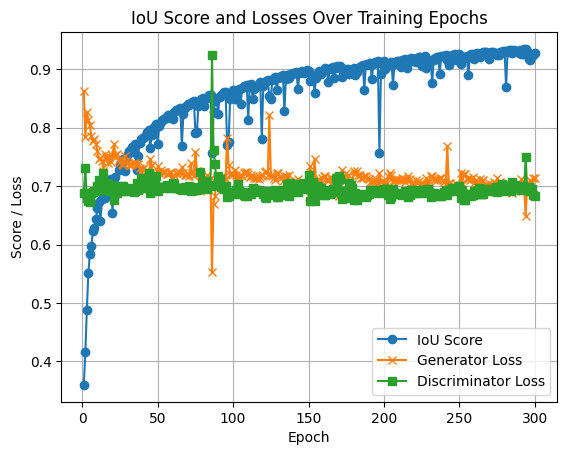

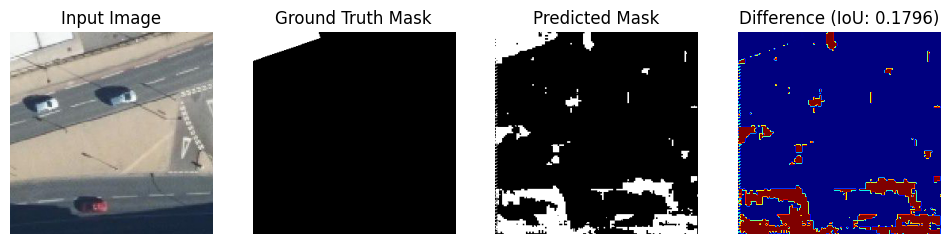

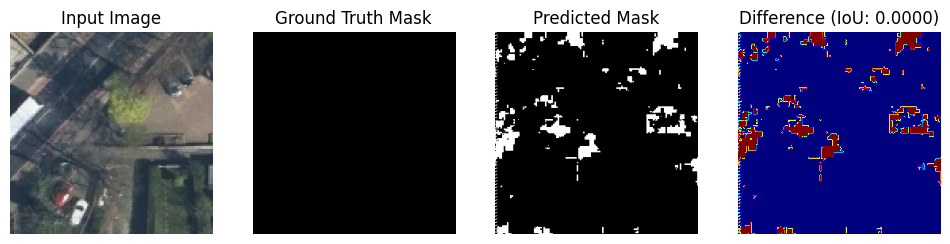

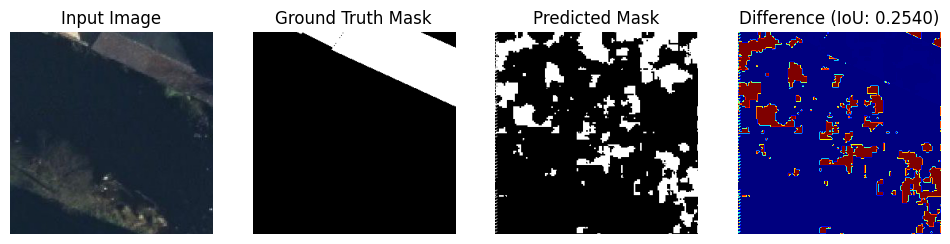

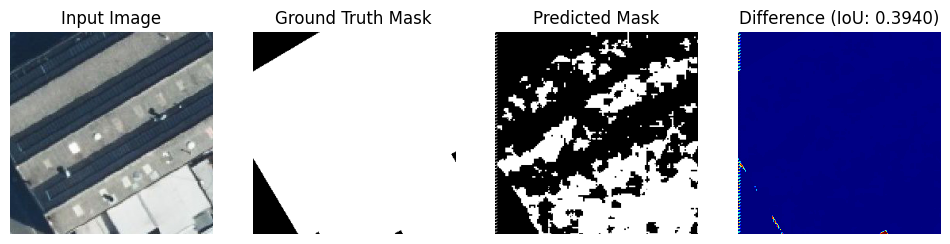

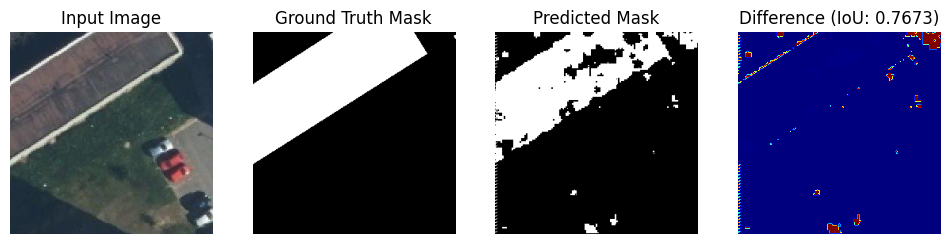

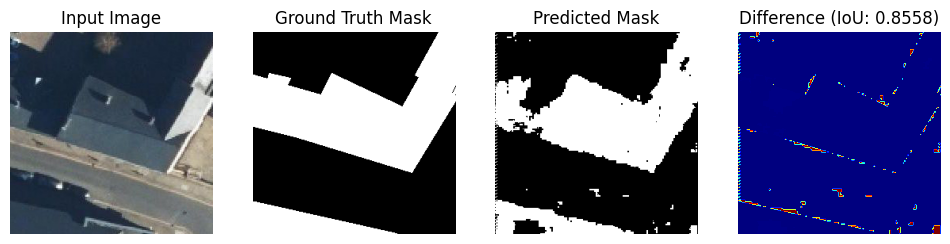

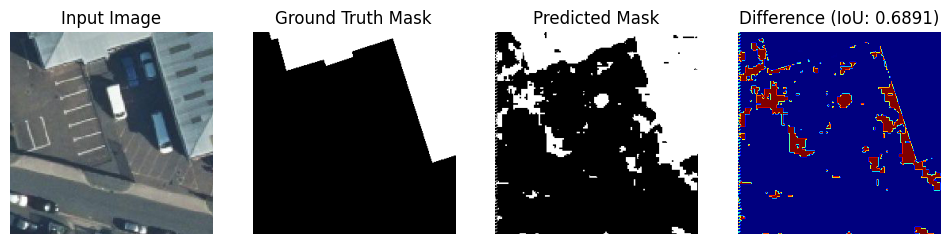

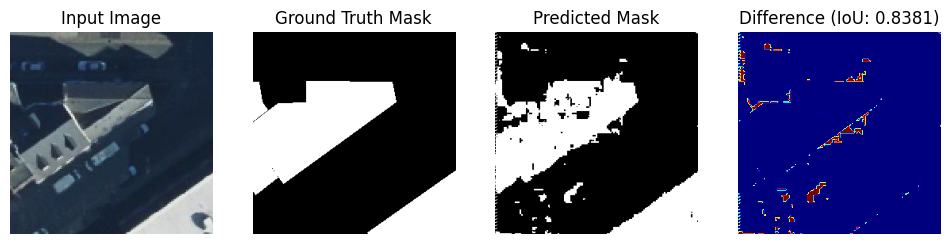

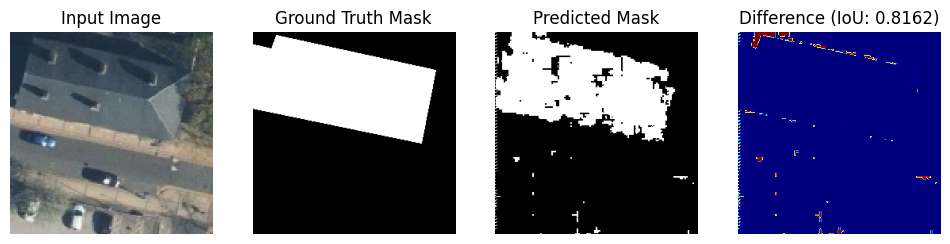

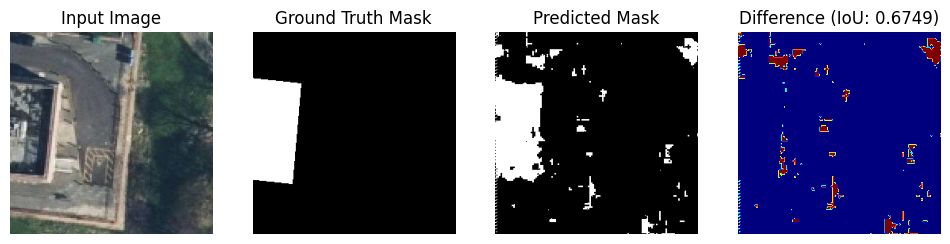

In [8]:

# Plot IoU scores and losses
plt.plot(range(1, EPOCHS + 1), iou_scores, marker='o', linestyle='-', label='IoU Score')
plt.plot(range(1, EPOCHS + 1), gen_losses, marker='x', linestyle='-', label='Generator Loss')
plt.plot(range(1, EPOCHS + 1), disc_losses, marker='s', linestyle='-', label='Discriminator Loss')
plt.xlabel("Epoch")
plt.ylabel("Score / Loss")
plt.title("IoU Score and Losses Over Training Epochs")
plt.legend()
plt.grid()
plt.show()

def calculate_image_iou(pred_mask, true_mask):
    pred_mask = pred_mask > 0.5
    true_mask = true_mask > 0.5
    intersection = (pred_mask & true_mask).sum()
    union = (pred_mask | true_mask).sum()
    iou = intersection / union if union > 0 else 1.0
    return iou

def visualize_results(input_img, true_mask, pred_mask):
    """
    Display input image, ground truth mask, predicted mask, and the difference.

    :param input_img: Original image (numpy array)
    :param true_mask: Ground truth binary mask (numpy array)
    :param pred_mask: Predicted binary mask (numpy array)
    """
    # Ensure input image has 3 channels
    if input_img.shape[-1] != 3:
        raise ValueError(f"Expected input image with 3 channels, got {input_img.shape[-1]} channels")

    # Ensure masks have a single channel
    if len(true_mask.shape) == 3:
        true_mask = true_mask.squeeze()
    if len(pred_mask.shape) == 3:
        pred_mask = pred_mask.squeeze()

    diff = np.abs(true_mask - pred_mask)  # Highlight differences
    iou = calculate_image_iou(pred_mask, true_mask)  # Calculate IoU

    fig, ax = plt.subplots(1, 4, figsize=(12, 4))
    ax[0].imshow(input_img)
    ax[0].set_title("Input Image")

    ax[1].imshow(true_mask, cmap="gray")
    ax[1].set_title("Ground Truth Mask")

    ax[2].imshow(pred_mask, cmap="gray")
    ax[2].set_title("Predicted Mask")

    ax[3].imshow(diff, cmap="jet")
    ax[3].set_title(f"Difference (IoU: {iou:.4f})")

    for a in ax:
        a.axis("off")

    plt.show()

# Select 10 samples for visualization
num_samples = 10
indices = np.random.choice(len(X), num_samples, replace=False)

for idx in indices:
    sample_input = X[idx]
    sample_true_mask = Y[idx]

    # Convert to tensor and predict
    with torch.no_grad():
        input_tensor = torch.tensor(sample_input).to(device).permute(2, 0, 1).unsqueeze(0)  # Add batch dim
        pred_mask_tensor = generator(input_tensor)
        pred_mask = (pred_mask_tensor.cpu().numpy() > 0.5).astype(np.uint8).squeeze()  # Binarize

    # Visualize
    visualize_results(sample_input, sample_true_mask, pred_mask)